In [1]:
!pip install ultralytics opencv-python-headless scikit-learn pyyaml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 38.9 MB/s eta 0:00:00


In [2]:


import random, os, numpy as np, torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

os.environ["PYTHONHASHSEED"] = str(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [3]:
!ls /content/drive/MyDrive/agrivision_sem_2/

'leaf disease.yolov8.zip'


In [4]:
!unzip -q "/content/drive/MyDrive/agrivision_sem_2/leaf disease.yolov8.zip" -d /content/

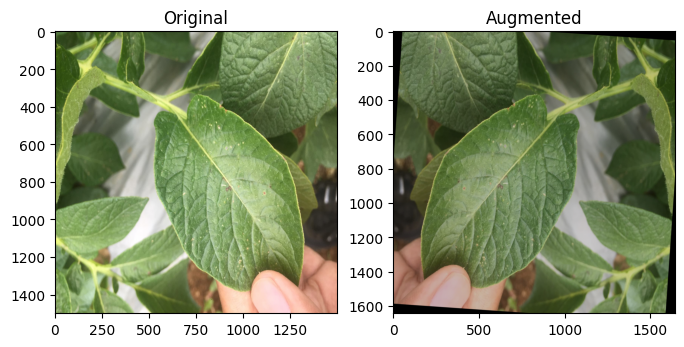

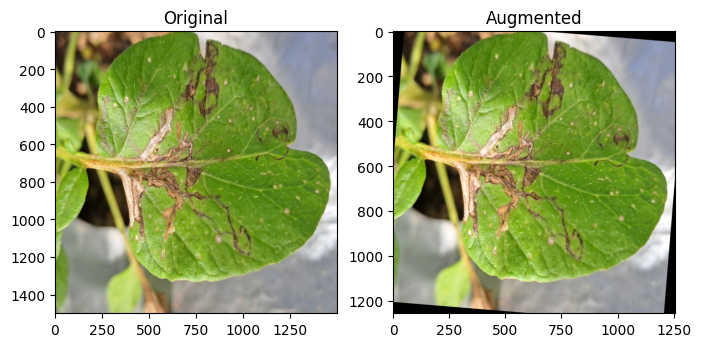

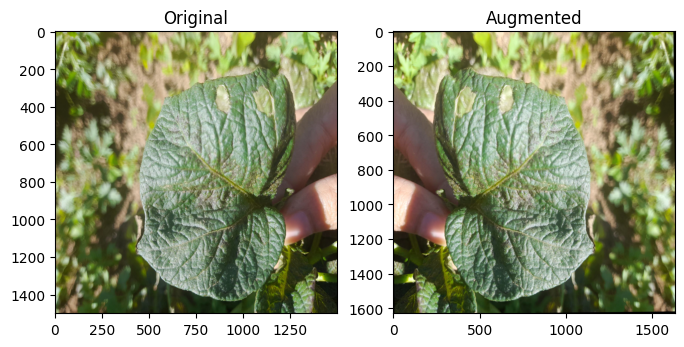

In [5]:
import os
import cv2
import random
import matplotlib.pyplot as plt

# Path to the images folder
DATA_ROOT = "/content/train/images"

# Pick all .jpg images in that folder
images = [f for f in os.listdir(DATA_ROOT) if f.endswith(".jpg")]

# Sample 3 random images
sample_imgs = random.sample(images, 3)

def augment_image(img):
    h, w = img.shape[:2]

    # flip
    if random.random() < 0.5:
        img = cv2.flip(img, 1)

    # brightness
    value = random.uniform(0.7, 1.3)
    img = cv2.convertScaleAbs(img, alpha=value, beta=0)

    # rotation
    angle = random.uniform(-5, 5)
    M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1)
    img = cv2.warpAffine(img, M, (w, h))

    # scale (zoom)
    scale = random.uniform(0.8, 1.2)
    resized = cv2.resize(img, None, fx=scale, fy=scale)

    return resized

# Show original and augmented images
for img_name in sample_imgs:
    img_path = os.path.join(DATA_ROOT, img_name)
    img = cv2.imread(img_path)

    aug_img = augment_image(img)

    plt.figure(figsize=(8,4))
    plt.subplot(1,2,1)
    plt.title("Original")
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

    plt.subplot(1,2,2)
    plt.title("Augmented")
    plt.imshow(cv2.cvtColor(aug_img, cv2.COLOR_BGR2RGB))
    plt.show()

In [6]:
from pathlib import Path
from sklearn.model_selection import train_test_split
import shutil, os
import yaml

DATA_ROOT = "/content/train"
SEED = 42

root = Path(DATA_ROOT)
images = list((root / "images").glob("*.jpg"))

train, temp = train_test_split(images, test_size=0.3, random_state=SEED)
val, test = train_test_split(temp, test_size=0.5, random_state=SEED)

for s in ["train","val","test"]:
    os.makedirs(root / s / "images", exist_ok=True)
    os.makedirs(root / s / "labels", exist_ok=True)

def move(files, split):
    for img in files:
        lbl = root / "labels" / (img.stem + ".txt")
        if not lbl.exists(): continue
        shutil.copy(img, root / split / "images" / img.name)
        shutil.copy(lbl, root / split / "labels" / lbl.name)

move(train,"train")
move(val,"val")
move(test,"test")

DATA_ROOT = "/content"  # root path where train/valid/test folders exist
root = Path(DATA_ROOT)

data = {
    "path": "/content/train",   # parent folder
    "train": "train/images",    # /content/train/train/images
    "val": "val/images",        # /content/train/val/images
    "test": "test/images",      # /content/train/test/images
    "names": [
        "maize fall armyworm",
        "maize healthy",
        "maize leaf blight",
        "potato healthy",
        "potato late blight",
        "potato pest damage",
        "tomato early blight",
        "tomato healthy",
        "tomato leaf miner"
    ]
}

with open("/content/train/data.yaml","w") as f:
    yaml.dump(data, f)

In [7]:
from ultralytics import YOLO

model = YOLO("yolov8n-seg.pt")


model.train(
    data="/content/train/data.yaml",
    epochs=50,
    imgsz=416,
    batch=16,
    patience=5,
    device=0,
    project="runs",
    name="leaf_optionB",
    fliplr=0.5,     # flip left-right (good for leaves)
    hsv_v=0.3,      # brightness change (field conditions)
    scale=0.3,      # slight zoom
    degrees=5,      # small rotation only

    mosaic=0.3      # IMPORTANT: keep low for segmentation
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.28 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/train/data.yaml, degrees=5, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.3, imgsz=416, int8=False, 

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7, 8])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ef0a4458440>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,   

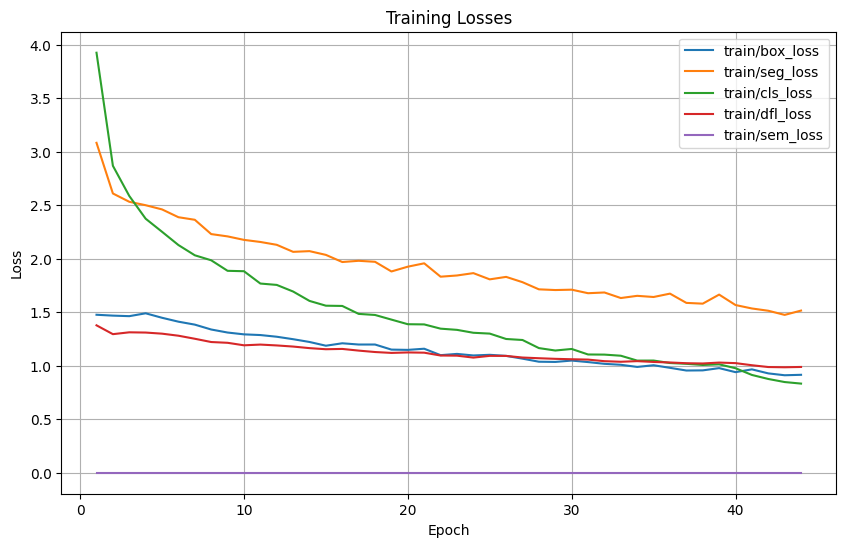

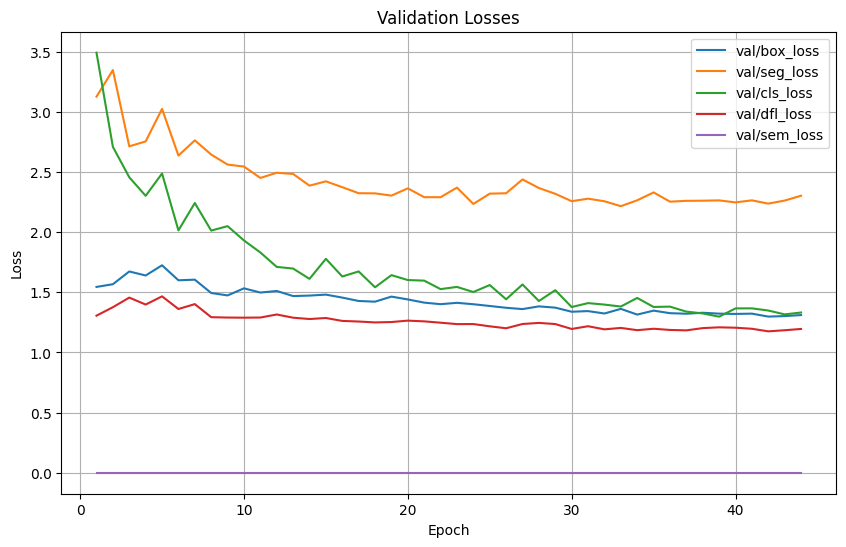

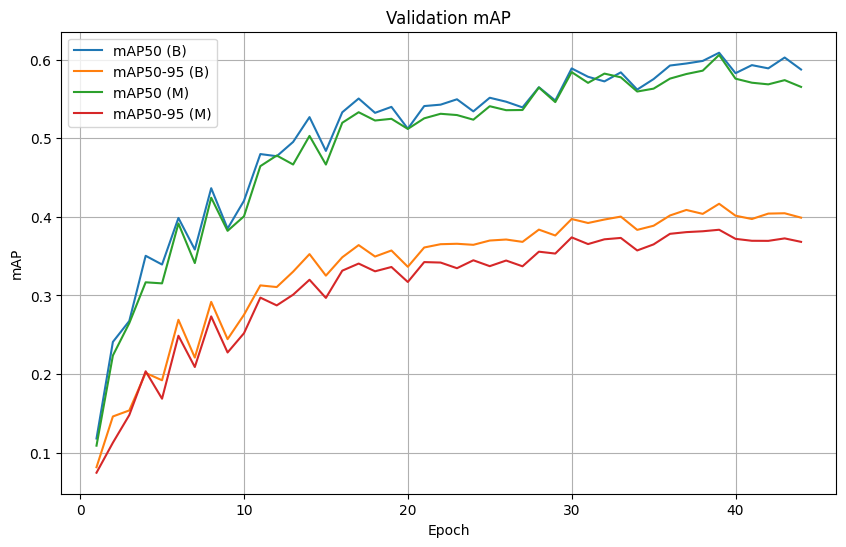

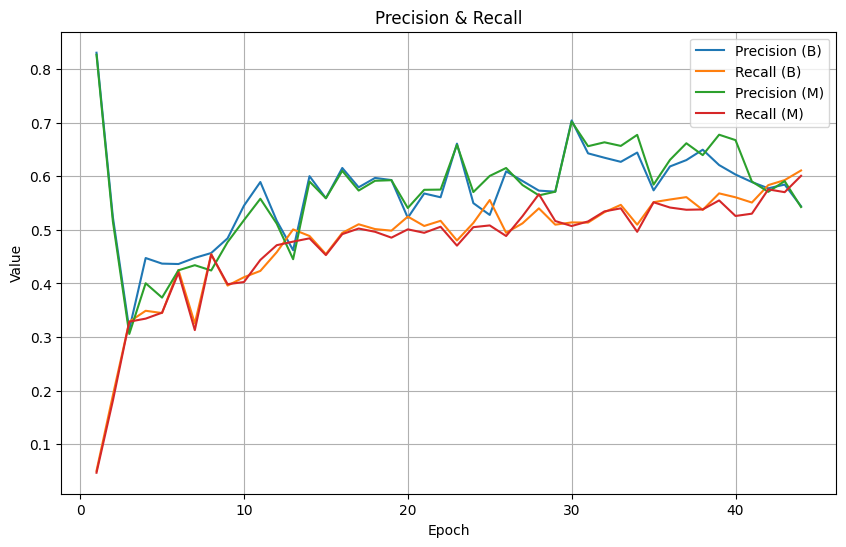

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV
csv_path = "/content/runs/segment/runs/leaf_optionB/results.csv"
df = pd.read_csv(csv_path)

# Plot training losses
plt.figure(figsize=(10,6))
plt.plot(df['epoch'], df['train/box_loss'], label='train/box_loss')
plt.plot(df['epoch'], df['train/seg_loss'], label='train/seg_loss')
plt.plot(df['epoch'], df['train/cls_loss'], label='train/cls_loss')
plt.plot(df['epoch'], df['train/dfl_loss'], label='train/dfl_loss')
plt.plot(df['epoch'], df['train/sem_loss'], label='train/sem_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Losses')
plt.legend()
plt.grid(True)
plt.show()

# Plot validation losses
plt.figure(figsize=(10,6))
plt.plot(df['epoch'], df['val/box_loss'], label='val/box_loss')
plt.plot(df['epoch'], df['val/seg_loss'], label='val/seg_loss')
plt.plot(df['epoch'], df['val/cls_loss'], label='val/cls_loss')
plt.plot(df['epoch'], df['val/dfl_loss'], label='val/dfl_loss')
plt.plot(df['epoch'], df['val/sem_loss'], label='val/sem_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Validation Losses')
plt.legend()
plt.grid(True)
plt.show()

# Plot mAP curves
plt.figure(figsize=(10,6))
plt.plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP50 (B)')
plt.plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP50-95 (B)')
plt.plot(df['epoch'], df['metrics/mAP50(M)'], label='mAP50 (M)')
plt.plot(df['epoch'], df['metrics/mAP50-95(M)'], label='mAP50-95 (M)')
plt.xlabel('Epoch')
plt.ylabel('mAP')
plt.title('Validation mAP')
plt.legend()
plt.grid(True)
plt.show()

# Optional: Plot precision and recall
plt.figure(figsize=(10,6))
plt.plot(df['epoch'], df['metrics/precision(B)'], label='Precision (B)')
plt.plot(df['epoch'], df['metrics/recall(B)'], label='Recall (B)')
plt.plot(df['epoch'], df['metrics/precision(M)'], label='Precision (M)')
plt.plot(df['epoch'], df['metrics/recall(M)'], label='Recall (M)')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('Precision & Recall')
plt.legend()
plt.grid(True)
plt.show()

In [18]:
# Validation metrics
val_metrics = model.val(data="/content/train/data.yaml")

val_box_mAP50 = val_metrics.box.map50
val_box_mAP5095 = val_metrics.box.map  # this is the correct attribute
val_box_precision = val_metrics.box.mp
val_box_recall = val_metrics.box.mr
val_box_loss = val_metrics.box.loss if hasattr(val_metrics.box, 'loss') else None

print(f"Validation metrics:")
print(f"Box mAP50: {val_box_mAP50:.3f}")
print(f"Box mAP50-95: {val_box_mAP5095:.3f}")
print(f"Box Precision: {val_box_precision:.3f}")
print(f"Box Recall: {val_box_recall:.3f}")
print(f"Box Loss: {val_box_loss}")
# Test metrics
test_metrics = model.val(data="/content/train/data.yaml", split="test")

# Test metrics
test_box_mAP50 = test_metrics.box.map50
test_box_mAP5095 = test_metrics.box.map
# Convert arrays to mean
test_box_precision = np.mean(test_metrics.box.mp) if isinstance(test_metrics.box.mp, np.ndarray) else test_metrics.box.mp
test_box_recall = np.mean(test_metrics.box.mr) if isinstance(test_metrics.box.mr, np.ndarray) else test_metrics.box.mr
test_box_loss = None  # YOLOv8 does not always store loss in .box

print("Test metrics:")
print(f"Box mAP50: {test_box_mAP50:.3f}")
print(f"Box mAP50-95: {test_box_mAP5095:.3f}")
print(f"Box Precision: {test_box_precision:.3f}")
print(f"Box Recall: {test_box_recall:.3f}")
print(f"Box Loss: {test_box_loss}")

Ultralytics 8.4.28 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1180.7±1217.0 MB/s, size: 324.0 KB)
val: Scanning /content/train/val/labels.cache... 180 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 180/180 47.2Mit/s 0.0s
val: /content/train/val/images/mfa_000006_jpg.rf.zHWzCqicK8DSPkrQ8v08.jpg: corrupt JPEG restored and saved
val: /content/train/val/images/mfa_000022_jpg.rf.bb5XMWwpuhNHx1Q1COdl.jpg: corrupt JPEG restored and saved
val: /content/train/val/images/mfa_000030_jpg.rf.nZlVsmhEDQqIEXIWjZUR.jpg: corrupt JPEG restored and saved
val: /content/train/val/images/mfa_000032_jpg.rf.kgdfAAqsE01RFylv5tZ0.jpg: corrupt JPEG restored and saved
val: /content/train/val/images/mfa_000040_jpg.rf.2us6WE6ZQiQGBNQ0U5p2.jpg: corrupt JPEG restored and saved
val: /content/train/val/images/mfa_000101_jpg.rf.oPZOwXruMFYxx1Wzg1Dc.jpg: corrupt JPEG restored and saved
val: /content/train/val/images/mfa_000124_jpg.rf.HAvcPPlvovku

In [20]:
import shutil

best_model = "runs/segment/runs/leaf_optionB/weights/best.pt"
save_path = "/content/drive/MyDrive/agrivision_sem_2/leaf_model_1.pt"

shutil.copy(best_model, save_path)

'/content/drive/MyDrive/agrivision_sem_2/leaf_model_1.pt'

In [ ]:
# from ultralytics import YOLO
# model = YOLO("/content/drive/MyDrive/agrivision_sem_2/leaf_model_1.pt")


image 1/1 /content/test.jpg: 416x416 3 tomato early blights, 24.5ms
Speed: 4.0ms preprocess, 24.5ms inference, 3.5ms postprocess per image at shape (1, 3, 416, 416)
Detected class: tomato early blight
Detected class: tomato early blight
Detected class: tomato early blight


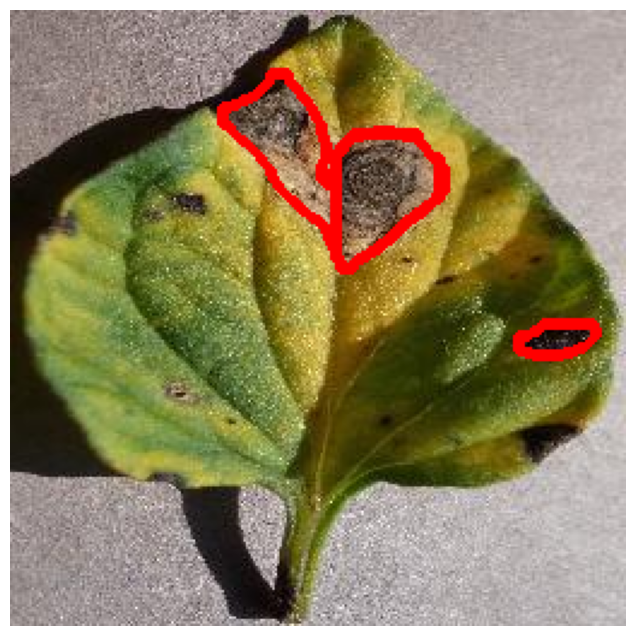

In [42]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def run_inference(image_path):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h_img, w_img = img.shape[:2]

    results = model(image_path)[0]

    for i in range(len(results.boxes)):
        cls = int(results.boxes.cls[i])
        name = model.names[cls]
        print(f"Detected class: {name}")

        if results.masks is None:
            continue

        # Get the mask
        mask = results.masks.data[i].cpu().numpy()  # shape (H,W)
        mask = (mask > 0.5).astype(np.uint8)
        mask = cv2.resize(mask, (w_img, h_img), interpolation=cv2.INTER_NEAREST)

        if np.sum(mask) == 0:
            continue

        # Draw polygons for each disease spot
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for cnt in contours:
            cv2.polylines(img, [cnt], isClosed=True, color=(255,0,0), thickness=3)

    return img

# Run inference
out_img = run_inference("/content/test.jpg")

# Display image with polygons
plt.figure(figsize=(8,8))
plt.imshow(out_img)
plt.axis('off')
plt.show()

In [35]:
model.export(format="tflite", imgsz=320, half=True)

Ultralytics 8.4.28 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/content/runs/segment/runs/leaf_optionB/weights/best.pt' with input shape (1, 3, 320, 320) BCHW and output shape(s) ((1, 45, 2100), (1, 32, 80, 80)) (6.4 MB)
requirements: Ultralytics requirements ['sng4onnx>=1.0.1', 'onnx_graphsurgeon>=0.3.26', 'ai-edge-litert>=1.2.0', 'onnx>=1.12.0,<2.0.0', 'onnx2tf>=1.26.3,<1.29.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 18 packages in 2.79s
Prepared 9 packages in 6.27s
Installed 9 packages in 306ms
 + ai-edge-litert==2.1.3
 + backports-strenum==1.3.1
 + colorama==0.4.6
 + onnx==1.20.1
 + onnx-graphsurgeon==0.5.8
 + onnx2tf==1.28.8
 + onnxruntime-gpu==1.24.4
 + onnxslim==0.1.90
 + sng4onnx==2.0.1

requirements: Auto

'/content/runs/segment/runs/leaf_optionB/weights/best_saved_model/best_float16.tflite'

In [9]:
from ultralytics import YOLO
import tensorflow as tf

models = {
    "best_float16": "/content/runs/segment/runs/leaf_optionB/weights/best_saved_model/best_float16.tflite",
    "best_int8": "/content/runs/segment/runs/leaf_optionB/weights/best_saved_model/best_int8.tflite"
}

data_yaml = "/content/train/data.yaml"

for name, model_path in models.items():
    print(f"\nEvaluating model: {name}")

    model = YOLO(model_path)

    # Get TFLite input size
    interpreter = tf.lite.Interpreter(model_path=model_path)
    interpreter.allocate_tensors()
    input_shape = interpreter.get_input_details()[0]['shape']
    input_size = int(input_shape[2])

    results = model.val(
        data=data_yaml,
        imgsz=input_size,
        task='segment',
        verbose=True
    )

    # Overall metrics
    summary = results.mean_results()
    print(f"\nModel: {name}")
    print(f"Precision: {summary[0]:.4f}")
    print(f"Recall: {summary[1]:.4f}")
    print(f"mAP50: {summary[2]:.4f}")
    print(f"mAP50-95: {summary[3]:.4f}")

    # Optional: per-class metrics
    results.summary()


Evaluating model: best_float16
Ultralytics 8.4.28 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Loading /content/runs/segment/runs/leaf_optionB/weights/best_saved_model/best_float16.tflite for TensorFlow Lite inference...
Setting batch=1 input of shape (1, 3, 320, 320)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2321.9±1154.3 MB/s, size: 1509.4 KB)
val: Scanning /content/train/val/labels.cache... 180 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 180/180 68.6Mit/s 0.0s
val: /content/train/val/images/mfa_000006_jpg.rf.zHWzCqicK8DSPkrQ8v08.jpg: corrupt JPEG restored and saved
val: /content/train/val/images/mfa_000022_jpg.rf.bb5XMWwpuhNHx1Q1COdl.jpg: corrupt JPEG restored and saved
val: /content/train/val/images/mfa_000030_jpg.rf.nZlVsmhEDQqIEXIWjZUR.jpg: corrupt JPEG restored and saved
val: /content/train/val/images/mfa_000032_jpg.rf.kgdfAAqsE01RFylv5tZ0.jpg: corrupt JPEG restored and saved
val: /content/train/val/images/mfa_000040_jpg.rf.2us6WE6ZQiQGBNQ0U5p

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 180/180 11.6it/s 15.5s
                   all        180        541      0.586      0.551      0.561       0.38       0.58       0.54      0.541      0.355
   maize fall armyworm         23        108      0.545      0.259      0.301      0.126      0.449      0.194      0.215     0.0659
         maize healthy         21         62      0.661      0.839      0.811      0.642       0.66      0.806      0.788      0.619
     maize leaf blight         20         83      0.655      0.388      0.452      0.249      0.605      0.351      0.401      0.211
        potato healthy         19         38      0.643      0.816      0.829      0.728      0.647      0.816      0.828      0.729
    potato late blight         25         47      0.625       0.66      0.649      0.373      0.655      0.681      0.644      0.353
    potato pest damage     

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 180/180 10.7it/s 16.8s
                   all        180        541      0.589      0.542      0.561      0.381      0.583      0.533      0.545      0.354
   maize fall armyworm         23        108      0.552       0.25      0.293      0.128      0.462      0.199      0.222     0.0661
         maize healthy         21         62      0.718      0.823      0.809       0.65      0.694       0.79      0.785      0.611
     maize leaf blight         20         83       0.64      0.365      0.447      0.247      0.623      0.337       0.41      0.207
        potato healthy         19         38      0.657      0.816       0.83      0.726      0.661      0.816      0.828      0.724
    potato late blight         25         47      0.616       0.66      0.649      0.374      0.638      0.681      0.656      0.351
    potato pest damage     